# Bibliotheken und Einstellungen
Diese Zelle zuerst ausführen. Alle Imports stehen gesammelt am Anfang.

In [4]:
# Kleine Anzeigehilfe: Name links, blauer Balken, Prozentzahl rechts.
from IPython.display import display, HTML
from html import escape

def show_progress(name, completed, total, bar=None):
    percent = round(100 * completed / total)
    progress_html = (
        '<div style="display:flex;align-items:center;gap:12px;margin:8px 0;">'
        f'<span style="min-width:180px;">{escape(name)}</span>'
        '<div style="flex:1;background:#dbe4ed;border-radius:6px;height:16px;">'
        f'<div style="width:{percent}%;background:#2196f3;height:16px;'
        'border-radius:6px;"></div></div>'
        f'<span style="min-width:48px;text-align:right;">{percent}%</span></div>'
    )
    if bar is None:
        return display(HTML(progress_html), display_id=True)
    bar.update(HTML(progress_html))
    return bar

%pip install hyperopt


from functools import partial
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval


# Alle Imports für den geplanten Workflow: sechs Gruppen.
import_bar = show_progress("Bibliotheken laden", 0, 6)
from pathlib import Path
import time
show_progress("Standardbibliotheken", 1, 6, import_bar)

import joblib
import numpy as np
import pandas as pd
show_progress("Tabellenbibliotheken", 2, 6, import_bar)
import matplotlib.pyplot as plt
import seaborn as sns
show_progress("Grafikbibliotheken", 3, 6, import_bar)
from scipy.stats import randint, loguniform, uniform
show_progress("SciPy", 4, 6, import_bar)

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
show_progress("Vorverarbeitungsbibliotheken", 5, 6, import_bar)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
show_progress("Bibliotheken geladen", 6, 6, import_bar)
print("Imports abgeschlossen. Noch kein Training durchgeführt.")


Note: you may need to restart the kernel to use updated packages.


Imports abgeschlossen. Noch kein Training durchgeführt.


# CSV einfach laden

In [ ]:
# Die bereinigte CSV liegt im Projektordner unter data/data_clean_MP.csv.
# Unterstützt den Start im Projekt-Hauptordner oder direkt in notebooks/.
project_dir = Path.cwd()
if not (project_dir / "data" / "data_clean_MP.csv").is_file():
    if (project_dir.parent / "data" / "data_clean_MP.csv").is_file():
        project_dir = project_dir.parent

CSV_PATH = project_dir / "data" / "data_clean_MP.csv"

if not CSV_PATH.is_file():
    raise FileNotFoundError(
        "CSV nicht gefunden. Lege data_clean_MP.csv im Projekt-Unterordner data ab "
        "und starte das Notebook im Projekt-Hauptordner oder im Ordner notebooks. "
        f"Geprüfter Pfad: {CSV_PATH}"
    )

load_bar = show_progress("CSV laden", 0, 1)
df = pd.read_csv(CSV_PATH)
show_progress("CSV geladen", 1, 1, load_bar)

print("Geladene Datei:", CSV_PATH.name)
print(f"Dimensionen: {df.shape[0]:,} Zeilen, {df.shape[1]} Spalten")
print("Spalten:", df.columns.tolist())
display(df.head(5))


Geladene Datei: data_clean_MP.csv
Dimensionen: 19,587 Zeilen, 23 Spalten
Spalten: ['N6', 'N8', 'N7', 'N1', 'N9', 'N10', 'N3', 'N5', 'E3', 'N2', 'E5', 'N4', 'E7', 'E4', 'age', 'C4', 'E1', 'A4', 'E10', 'E9', 'gender', 'hand', 'target']


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,5,5,4,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,3,2,1,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,5,5,1,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,3,2,3,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,3,4,3,3,25,3,3,5,5,3,Female,Right,Moderate


# Definition von X und y
target wird ausschließlich als Zielvariable verwendet. hand bleibt in X enthalten. Es werden keine Werte verändert oder Vorverarbeitungsschritte trainiert.

In [3]:
# Eingabemerkmale und Zielvariable trennen; hand bleibt enthalten.
feature_bar = show_progress("Spalten prüfen", 0, 3)
required_columns = {
    "N6", "N8", "N7", "N1", "N9", "N10", "N3", "N5",
    "E3", "N2", "E5", "N4", "E7", "E4", "age", "C4",
    "E1", "A4", "E10", "E9", "gender", "hand", "target",
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Benötigte Spalten fehlen: {sorted(missing_columns)}")
if df["target"].isna().any():
    raise ValueError("target enthält fehlende Werte. Bitte vor dem Training klären.")
show_progress("Spalten geprüft", 1, 3, feature_bar)

X = df.drop(columns=["target"]).copy()
y = df["target"].copy()
show_progress("X und y getrennt", 2, 3, feature_bar)

# gender und hand sind Kategorien, auch wenn sie als Zahlen codiert wären.
categorical_features = [
    column for column in X.columns
    if column in {"gender", "hand"}
    or not pd.api.types.is_numeric_dtype(X[column])
]
numeric_features = [
    column for column in X.columns if column not in categorical_features
]
show_progress("Merkmale bestimmt", 3, 3, feature_bar)

print("Numerische Merkmale:", numeric_features)
print("Kategoriale Merkmale:", categorical_features)
print("Target: target")


Numerische Merkmale: ['N6', 'N8', 'N7', 'N1', 'N9', 'N10', 'N3', 'N5', 'E3', 'N2', 'E5', 'N4', 'E7', 'E4', 'age', 'C4', 'E1', 'A4', 'E10', 'E9']
Kategoriale Merkmale: ['gender', 'hand']
Target: target


# Vorverarbeitung definieren
Numerische Merkmale: fehlende Werte werden mit dem Median ersetzt und standardisiert. 

Kategorien: der häufigste Wert wird einsetzt und One-Hot-Encoding verwendet. 

In [4]:
# Hier werden nur die Schritte definiert, noch keine Werte gelernt.
preprocessing_bar = show_progress("Vorverarbeitung definieren", 0, 1)
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
], remainder="drop", sparse_threshold=0)
show_progress("Vorverarbeitung definiert", 1, 1, preprocessing_bar)

print("Vorverarbeitung definiert. Noch kein fit ausgeführt.")


Vorverarbeitung definiert. Noch kein fit ausgeführt.


# Vier Modell-Pipelines erstellen
Jede Pipeline verbindet Vorverarbeitung und Modell. Jede eigene Kopie verhindert, dass die Pipelines einen gemeinsam trainierten Preprocessor teilen. Welches Modell gewinnt, entscheiden später die CV-Ergebnisse.

In [5]:
# Jede Pipeline erhält eine eigene Kopie der Vorverarbeitung.
pipeline_bar = show_progress("Pipelines erstellen", 0, 4)
pipe_logreg = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])
show_progress("LogisticRegression erstellt", 1, 4, pipeline_bar)

pipe_knn = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", KNeighborsClassifier()),
])
show_progress("KNN erstellt", 2, 4, pipeline_bar)

pipe_rf = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(random_state=42)),
])
show_progress("RandomForest erstellt", 3, 4, pipeline_bar)

pipe_hgb = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", HistGradientBoostingClassifier(random_state=42)),
])
show_progress("HistGradientBoosting erstellt", 4, 4, pipeline_bar)

# Gemeinsame Sammlung für späteren Vergleich und Hyperparameter-Suche.
pipelines = {
    "pipe_logreg": pipe_logreg,
    "pipe_knn": pipe_knn,
    "pipe_rf": pipe_rf,
    "pipe_hgb": pipe_hgb,
}

pipeline_overview = pd.DataFrame([
    {
        "Pipeline": "pipe_logreg",
        "Modell": "LogisticRegression",
        "Familie": "Lineares Modell",
        "Warum?": "Einfacher, gut interpretierbarer Ausgangspunkt.",
    },
    {
        "Pipeline": "pipe_knn",
        "Modell": "KNeighborsClassifier",
        "Familie": "Distanzbasiert",
        "Warum?": "Klassifiziert anhand ähnlicher Antworten; Skalierung ist wichtig.",
    },
    {
        "Pipeline": "pipe_rf",
        "Modell": "RandomForestClassifier",
        "Familie": "Bagging / Entscheidungsbäume",
        "Warum?": "Erfasst nichtlineare Zusammenhänge und Merkmalskombinationen.",
    },
    {
        "Pipeline": "pipe_hgb",
        "Modell": "HistGradientBoostingClassifier",
        "Familie": "Boosting / Entscheidungsbäume",
        "Warum?": "Histogrammbasiertes Boosting als weiterer Kandidat für Tabellendaten.",
    },
])

# HTML-Anzeige mit Zeilenumbrüchen, ohne Pandas-Styler.
table_css = '''
<style>
table.pipeline-table { width: 100%; table-layout: fixed; border-collapse: collapse; }
table.pipeline-table th, table.pipeline-table td {
    white-space: normal; overflow-wrap: anywhere;
    text-align: left; vertical-align: top; padding: 8px;
}
table.pipeline-table th:nth-child(1) { width: 15%; }
table.pipeline-table th:nth-child(2) { width: 25%; }
table.pipeline-table th:nth-child(3) { width: 20%; }
table.pipeline-table th:nth-child(4) { width: 40%; }
</style>
'''

table_html = pipeline_overview.to_html(index=False, classes="pipeline-table", border=0)
display(HTML(table_css + table_html))
print("Vier Pipelines erstellt. Noch kein Training und noch kein Gewinner.")


Pipeline,Modell,Familie,Warum?
pipe_logreg,LogisticRegression,Lineares Modell,"Einfacher, gut interpretierbarer Ausgangspunkt."
pipe_knn,KNeighborsClassifier,Distanzbasiert,Klassifiziert anhand ähnlicher Antworten; Skalierung ist wichtig.
pipe_rf,RandomForestClassifier,Bagging / Entscheidungsbäume,Erfasst nichtlineare Zusammenhänge und Merkmalskombinationen.
pipe_hgb,HistGradientBoostingClassifier,Boosting / Entscheidungsbäume,Histogrammbasiertes Boosting als weiterer Kandidat für Tabellendaten.


Vier Pipelines erstellt. Noch kein Training und noch kein Gewinner.


# Train-Test-Split
Wir reservieren 20 % der Daten als Testset. test_size=0.20 bestimmt diesen Anteil, stratify=y erhält ungefähr dieselben Klassenanteile. Alle vier Modelle verwenden dieselbe Aufteilung. Die Testdaten bleiben bis zur finalen Bewertung unberührt.

In [6]:
split_bar = show_progress("Train-Test-Split", 0, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
show_progress("Train-Test-Split abgeschlossen", 1, 1, split_bar)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)


Trainingsdaten: (15669, 22)
Testdaten: (3918, 22)


# Cross-Validation definieren
n_splits=5 legt fünf Durchläufe fest. shuffle=True mischt die Zeilen vor der Aufteilung; random_state=42 macht diese wiederholbar. StratifiedKFold berücksichtigt die Klassenanteile.

In [7]:
cv_bar = show_progress("CV-Aufteilung definieren", 0, 1)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
show_progress("CV-Aufteilung definiert", 1, 1, cv_bar)


<DisplayHandle display_id=8866aa9f6e9a6cf87f971d309699760a>

# Die Vier Pipelines trainieren und vergleichen
Die Schleife führt für jede Pipeline fünf CV-Trainings auf X_train und y_train aus: insgesamt 20 Trainingsläufe. Die Vorverarbeitung wird in jedem Durchlauf nur auf dessen Trainingsanteil gelernt.

Train F1-Macro: Wie gut erkennt das Modell die Klassen bei den Daten, mit denen es gelernt hat?

CV F1-Macro: Wie gut erkennt es die Klassen bei Daten, die es im jeweiligen Durchlauf noch nicht gesehen hat? Der Durchschnitt aus fünf Durchläufen ist unsere wichtigste Vergleichszahl.

CV F1-Streuung: Wie unterschiedlich sind die Ergebnisse der fünf Durchläufe? Eine kleine Streuung bedeutet gleichmäßigere Ergebnisse.

CV Accuracy: Welcher Anteil der Vorhersagen war richtig? 0,80 bedeutet beispielsweise 80 % richtige Vorhersagen.

In [8]:
from IPython.display import display, HTML

def show_results_table(
    data, highlight_best=False, decimals=4, highlight_times=False
):
    table = data.round(decimals).to_html(
        index=False, border=0, classes="results-table"
    )

    before, separator, body = table.partition("<tbody>")
    rows = body.split("<tr>")

    for number in range(1, len(rows)):
        row_style = ""

        if highlight_times:
            times = data.iloc[:, -1]
            value = times.iloc[number - 1]

            if value == times.min():
                row_style = "background:#153b60;color:white;"
            elif value == times.max():
                row_style = "background:#7f1d1d;color:white;"

        elif highlight_best and number == 1:
            row_style = "background:#153b60;color:white;"

        if row_style:
            row_style += "font-weight:bold;font-style:italic;"

        rows[number] = f'<tr style="{row_style}">' + rows[number]

    table = before + separator + "".join(rows)

    style = """
    <style>
    table.results-table {
        font-size: 16px;
        border-collapse: collapse;
    }
    table.results-table th,
    table.results-table td {
        padding: 10px 14px;
        text-align: left;
    }
    </style>
    """

    display(HTML(style + table))

In [9]:
results = []
timing_results = []

model_names = {
    "pipe_logreg": "LogisticRegression",
    "pipe_knn": "KNN",
    "pipe_rf": "RandomForest",
    "pipe_hgb": "HistGradientBoosting"
}

for name, pipeline in pipelines.items():
    model_name = model_names[name]
    model_bar = show_progress(f"CV: {model_name}", 0, cv.get_n_splits())

    start = time.time()

    # Jeden CV-Durchlauf einzeln ausführen, um echten Fortschritt zu zeigen.
    scores = {"train_f1_macro": [], "test_f1_macro": [], "test_accuracy": []}
    for fold, (train_indices, validation_indices) in enumerate(
        cv.split(X_train, y_train), start=1
    ):
        fold_scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=[(train_indices, validation_indices)],
            scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
            return_train_score=True,
            error_score="raise"
        )
        for metric in scores:
            scores[metric].append(fold_scores[metric][0])
        show_progress(f"CV: {model_name}", fold, cv.get_n_splits(), model_bar)

    # Arrays ermöglichen dieselbe Mittelwert-/Streuungsberechnung wie zuvor.
    scores = {metric: np.array(values) for metric, values in scores.items()}

    duration = time.time() - start
    timing_results.append({
        "Modell": model_name,
        "CV-Dauer (Sekunden)": duration
    })

    results.append({
        "Modell": model_name,
        "Train F1-Macro": scores["train_f1_macro"].mean(),
        "CV F1-Macro": scores["test_f1_macro"].mean(),
        "CV F1-Streuung": scores["test_f1_macro"].std(),
        "CV Accuracy": scores["test_accuracy"].mean()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("CV F1-Macro", ascending=False).reset_index(drop=True)
# display(HTML(results_df.round(4).to_html(index=False, border=0)))
show_results_table(results_df, highlight_best=True)


# Zeit für alle fünf CV-Durchläufe je Pipeline, inklusive Vorverarbeitung.
timing_df = pd.DataFrame(timing_results)
print("Laufzeiten der Cross-Validation:")
#display(HTML(timing_df.round(2).to_html(index=False, border=0)))
show_results_table(timing_df, decimals=2, highlight_times=True)


Modell,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,0.9411,0.7992,0.0083,0.8586
LogisticRegression,0.7689,0.7648,0.0066,0.8523
RandomForest,1.0000,0.7380,0.0045,0.8348
KNN,0.8067,0.7227,0.0061,0.8090


Laufzeiten der Cross-Validation:


Modell,CV-Dauer (Sekunden)
LogisticRegression,2.37
KNN,2.42
RandomForest,7.71
HistGradientBoosting,5.75


# Grid Search – Modelleinstellungen optimieren
Grid Search testet jede Kombination der angegebenen Einstellungen mit denselben fünf CV-Aufteilungen wie zuvor. Die Testdaten werden nicht verwendet.
Kleine Suchräume:

- **LogisticRegression – C:** kleinere Werte begrenzen die Modellgewichte stärker.
- **KNN – n_neighbors und weights:** Zahl der Nachbarn und gleiche Gewichtung (uniform) oder stärkeres Gewicht näherer Nachbarn (distance).
- **RandomForest – n_estimators, max_depth und min_samples_leaf:** Anzahl der Bäume, maximale Baumtiefe (None bedeutet keine feste Begrenzung) und Mindestzahl von Trainingsfällen pro Blatt. Begrenzungen können Overfitting verringern.
- **HistGradientBoosting – learning_rate, max_leaf_nodes und l2_regularization:** Schrittgröße, maximale Zahl der Blätter je Baum und eine Begrenzung großer Blattwerte.
Die Suchräume enthalten auch die bisherigen Ausgangseinstellungen. Insgesamt sind es 25 Kombinationen und damit 125 CV-Trainings plus vier abschließende Trainings der jeweils besten Pipeline.

In [10]:
# model__ spricht den Schritt "model" innerhalb der Pipeline an.
param_grids = {
    "pipe_logreg": {
        "model__C": [0.1, 1.0, 10.0]
    },
    "pipe_knn": {
        "model__n_neighbors": [5, 15, 25],
        "model__weights": ["uniform", "distance"]
    },
    "pipe_rf": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10],
        "model__min_samples_leaf": [1, 5]
    },
    "pipe_hgb": {
        "model__learning_rate": [0.05, 0.1],
        "model__max_leaf_nodes": [15, 31],
        "model__l2_regularization": [0.0, 1.0]
    }
}


In [11]:
grid_results = []
grid_timing_results = []
grid_parameter_results = []
grid_searches = {}
grid_bar = show_progress("Grid Search: vier Modelle", 0, len(pipelines))

for model_number, (name, pipeline) in enumerate(pipelines.items(), start=1):
    model_name = model_names[name]
    show_progress(f"Grid Search: {model_name}", model_number - 1, len(pipelines), grid_bar)

    grid_search = GridSearchCV(
        estimator=clone(pipeline),
        param_grid=param_grids[name],
        cv=cv,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        refit="f1_macro",
        return_train_score=True,
        n_jobs=1,
        error_score="raise"
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    duration = time.time() - start
    show_progress(f"Grid Search: {model_name} fertig", model_number, len(pipelines), grid_bar)

    # Ergebnisse und trainierte Gewinner-Pipeline dieses Suchlaufs behalten.
    grid_searches[name] = grid_search
    best_index = grid_search.best_index_
    search_scores = grid_search.cv_results_

    grid_results.append({
        "Modell": model_name,
        "Train F1-Macro": search_scores["mean_train_f1_macro"][best_index],
        "CV F1-Macro": search_scores["mean_test_f1_macro"][best_index],
        "CV F1-Streuung": search_scores["std_test_f1_macro"][best_index],
        "CV Accuracy": search_scores["mean_test_accuracy"][best_index]
    })
    grid_timing_results.append({
        "Modell": model_name,
        "Grid-Search-Dauer (Sekunden)": duration
    })
    grid_parameter_results.append({
        "Modell": model_name,
        "Beste Parameter": str(grid_search.best_params_)
    })

grid_results_df = pd.DataFrame(grid_results)
grid_results_df = grid_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

print("Grid Search: Ergebnisse der besten Einstellungen je Modell")
show_results_table(grid_results_df, highlight_best=True)
print("Blau, fett und kursiv: höchster CV-F1-Macro nach Grid Search.")

grid_timing_df = pd.DataFrame(grid_timing_results)
print("Laufzeiten inklusive abschließendem Training je Suchlauf:")
show_results_table(grid_timing_df, decimals=2, highlight_times=True)

grid_parameters_df = pd.DataFrame(grid_parameter_results)
print("Beste Parameter:")
display(HTML(table_css + grid_parameters_df.to_html(
    index=False, classes="pipeline-table", border=0
)))


Grid Search: Ergebnisse der besten Einstellungen je Modell


Modell,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,0.8812,0.8005,0.0056,0.8613
LogisticRegression,0.7697,0.7652,0.0061,0.8524
RandomForest,1.0000,0.7380,0.0045,0.8348
KNN,1.0000,0.7373,0.0043,0.8320


Blau, fett und kursiv: höchster CV-F1-Macro nach Grid Search.
Laufzeiten inklusive abschließendem Training je Suchlauf:


Modell,Grid-Search-Dauer (Sekunden)
LogisticRegression,6.33
KNN,12.29
RandomForest,73.49
HistGradientBoosting,42.76


Beste Parameter:


Modell,Beste Parameter
LogisticRegression,{'model__C': 10.0}
KNN,"{'model__n_neighbors': 15, 'model__weights': 'distance'}"
RandomForest,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}"
HistGradientBoosting,"{'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_leaf_nodes': 15}"


# Vorher und nachher vergleichen
Eine positive Veränderung bedeutet einen höheren CV-F1 nach Grid Search. Kleine Unterschiede können innerhalb der Schwankungen liegen. Die besten CV-Ergebnisse wurden für die Auswahl verwendet und sind daher keine unabhängige Abschlussprüfung.

In [12]:
# Pro Modell direkt sehen, ob Grid Search den CV-F1 verbessert hat.
grid_comparison_df = results_df[["Modell", "CV F1-Macro"]].merge(
    grid_results_df[["Modell", "CV F1-Macro"]],
    on="Modell",
    suffixes=(" vorher", " Grid Search")
)
grid_comparison_df["Veränderung"] = (
    grid_comparison_df["CV F1-Macro Grid Search"]
    - grid_comparison_df["CV F1-Macro vorher"]
)
grid_comparison_df = grid_comparison_df.sort_values(
    "CV F1-Macro Grid Search", ascending=False
)
show_results_table(grid_comparison_df, highlight_best=True)


Modell,CV F1-Macro vorher,CV F1-Macro Grid Search,Veränderung
HistGradientBoosting,0.7992,0.8005,0.0012
LogisticRegression,0.7648,0.7652,0.0003
RandomForest,0.7380,0.7380,0.0000
KNN,0.7227,0.7373,0.0146


# Randomized Search
Grid Search testet jede vorgegebene Kombination. Randomized Search zieht eine begrenzte Zahl von Kombinationen aus größeren Bereichen. Das kann andere gute Einstellungen finden, garantiert aber keine Verbesserung. Die Suche verwendet wieder ausschließlich die Trainingsdaten und dieselben fünf Cross Validation CV -Aufteilungen.

Die Parameter haben dieselbe Bedeutung wie bei Grid Search. Zusätzlich testen wir bei HistGradientBoosting max_iter: die maximale Anzahl der Boosting-Schritte. randint(3, 41) zieht beispielsweise ganze Zahlen von 3 bis 40. uniform(0, 5) zieht Werte zwischen 0 und 5. loguniform ist für positive Parameter wie C und die Lernrate geeignet, weil Werte in unterschiedlichen Größenordnungen berücksichtigt werden.



Suchbereiche:

In [13]:

param_distributions = {
    "pipe_logreg": {
        "model__C": loguniform(0.01, 100)
    },
    "pipe_knn": {
        "model__n_neighbors": randint(3, 41),
        "model__weights": ["uniform", "distance"]
    },
    "pipe_rf": {
        "model__n_estimators": randint(50, 251),
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": randint(1, 11)
    },
    "pipe_hgb": {
        "model__learning_rate": loguniform(0.02, 0.2),
        "model__max_leaf_nodes": randint(10, 41),
        "model__l2_regularization": uniform(0, 5),
        "model__max_iter": [100, 200]
    }
}


n_iter=12 bedeutet zwölf Versuche je Modell. Mit vier Modellen und fünf CV-Durchläufen entstehen 240 CV-Trainings plus vier abschließende Trainings der jeweils besten Pipeline. Die Suche bleibt zunächst mit n_jobs=1 einfach und führt CV-Trainings nacheinander aus.

In [14]:
random_results = []
random_timing_results = []
random_parameter_results = []
random_searches = {}
random_bar = show_progress("Randomized Search: vier Modelle", 0, len(pipelines))

for model_number, (name, pipeline) in enumerate(pipelines.items(), start=1):
    model_name = model_names[name]
    show_progress(
        f"Randomized Search: {model_name}",
        model_number - 1, len(pipelines), random_bar
    )

    random_search = RandomizedSearchCV(
        estimator=clone(pipeline),
        param_distributions=param_distributions[name],
        n_iter=12,
        cv=cv,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        refit="f1_macro",
        return_train_score=True,
        random_state=42,
        n_jobs=1,
        error_score="raise"
    )

    start = time.time()
    random_search.fit(X_train, y_train)
    duration = time.time() - start
    show_progress(
        f"Randomized Search: {model_name} fertig",
        model_number, len(pipelines), random_bar
    )

    random_searches[name] = random_search
    best_index = random_search.best_index_
    search_scores = random_search.cv_results_

    random_results.append({
        "Modell": model_name,
        "Train F1-Macro": search_scores["mean_train_f1_macro"][best_index],
        "CV F1-Macro": search_scores["mean_test_f1_macro"][best_index],
        "CV F1-Streuung": search_scores["std_test_f1_macro"][best_index],
        "CV Accuracy": search_scores["mean_test_accuracy"][best_index]
    })
    random_timing_results.append({
        "Modell": model_name,
        "Randomized-Search-Dauer (Sekunden)": duration
    })
    random_parameter_results.append({
        "Modell": model_name,
        "Beste Parameter": str(random_search.best_params_)
    })

random_results_df = pd.DataFrame(random_results)
random_results_df = random_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

print("Randomized Search: Ergebnisse der besten Einstellungen je Modell")
show_results_table(random_results_df, highlight_best=True)

random_timing_df = pd.DataFrame(random_timing_results)
print("Laufzeiten inklusive abschließendem Training je Suchlauf:")
show_results_table(random_timing_df, decimals=2, highlight_times=True)

random_parameters_df = pd.DataFrame(random_parameter_results)
print("Beste Parameter:")
display(HTML(table_css + random_parameters_df.to_html(
    index=False, classes="pipeline-table", border=0
)))


Randomized Search: Ergebnisse der besten Einstellungen je Modell


Modell,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,0.9109,0.8008,0.0063,0.8614
LogisticRegression,0.7697,0.7655,0.0060,0.8524
KNN,1.0000,0.7357,0.0094,0.8419
RandomForest,0.8620,0.7176,0.0043,0.8297


Laufzeiten inklusive abschließendem Training je Suchlauf:


Modell,Randomized-Search-Dauer (Sekunden)
LogisticRegression,23.53
KNN,26.14
RandomForest,143.74
HistGradientBoosting,190.25


Beste Parameter:


Modell,Beste Parameter
LogisticRegression,{'model__C': np.float64(63.512210106407046)}
KNN,"{'model__n_neighbors': 32, 'model__weights': 'distance'}"
RandomForest,"{'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__n_estimators': 210}"
HistGradientBoosting,"{'model__l2_regularization': np.float64(2.28034992108518), 'model__learning_rate': np.float64(0.12195678219063029), 'model__max_iter': 100, 'model__max_leaf_nodes': 21}"


# Gemeinsamer Vergleich
Wir führen die bisherigen Tabellen zusammen: vier Modelle mit jeweils drei Verfahren, also zwölf Zeilen. Die Spalte Verfahren zeigt, woher das Ergebnis stammt. Alle Scores stammen aus Cross-Validation, nicht aus den zurückgehaltenen Testdaten. Die erste Zeile ist der bisher beste Kandidat; Hyperopt folgt noch. Unterschiedliche Suchräume und Versuchszahlen bedeuten, dass wir die gefundenen Ergebnisse vergleichen und keine allgemeine Überlegenheit eines Suchverfahrens beweisen.

In [15]:
# Gleiche Spalten wie zuvor, zusätzlich das verwendete Suchverfahren.
tuning_results_df = pd.concat([
    results_df.assign(Verfahren="Ohne Tuning"),
    grid_results_df.assign(Verfahren="Grid Search"),
    random_results_df.assign(Verfahren="Randomized Search")
], ignore_index=True)

tuning_results_df = tuning_results_df[[
    "Modell", "Verfahren", "Train F1-Macro", "CV F1-Macro",
    "CV F1-Streuung", "CV Accuracy"
]]
tuning_results_df = tuning_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

print("Bisheriger Vergleich aller Modelle und Suchverfahren:")
show_results_table(tuning_results_df, highlight_best=True)


Bisheriger Vergleich aller Modelle und Suchverfahren:


Modell,Verfahren,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,Randomized Search,0.9109,0.8008,0.0063,0.8614
HistGradientBoosting,Grid Search,0.8812,0.8005,0.0056,0.8613
HistGradientBoosting,Ohne Tuning,0.9411,0.7992,0.0083,0.8586
LogisticRegression,Randomized Search,0.7697,0.7655,0.0060,0.8524
LogisticRegression,Grid Search,0.7697,0.7652,0.0061,0.8524
LogisticRegression,Ohne Tuning,0.7689,0.7648,0.0066,0.8523
RandomForest,Grid Search,1.0000,0.7380,0.0045,0.8348
RandomForest,Ohne Tuning,1.0000,0.7380,0.0045,0.8348
KNN,Grid Search,1.0000,0.7373,0.0043,0.8320
KNN,Randomized Search,1.0000,0.7357,0.0094,0.8419


# Hyperopt
Hyperopt ist unser drittes Suchverfahren. Es bewertet Parameterkombinationen anhand derselben Cross-Validation und desselben F1-Macro. Das TPE-Verfahren kann bisherige Versuche für weitere Vorschläge nutzen. Wir setzen fünf zufällige Startversuche fest; danach nutzt TPE die bisherigen Ergebnisse für weitere Vorschläge. partial hinterlegt dafür die Einstellung n_startup_jobs=5.



Suchräume:


In [16]:

hyperopt_spaces = {
    "pipe_logreg": {
        "model__C": hp.loguniform("logreg_C", np.log(0.01), np.log(100))
    },
    "pipe_knn": {
        "model__n_neighbors": hp.choice("knn_neighbors", list(range(3, 41))),
        "model__weights": hp.choice("knn_weights", ["uniform", "distance"])
    },
    "pipe_rf": {
        "model__n_estimators": hp.choice("rf_estimators", list(range(50, 251))),
        "model__max_depth": hp.choice("rf_depth", [None, 5, 10, 20]),
        "model__min_samples_leaf": hp.choice("rf_leaf", list(range(1, 11)))
    },
    "pipe_hgb": {
        "model__learning_rate": hp.loguniform(
            "hgb_learning_rate", np.log(0.02), np.log(0.2)
        ),
        "model__max_leaf_nodes": hp.choice("hgb_leaf_nodes", list(range(10, 41))),
        "model__l2_regularization": hp.uniform("hgb_l2", 0, 5),
        "model__max_iter": hp.choice("hgb_iterations", [100, 200])
    }
}


# Suche ausführen
Eine objective-Funktion bewertet eine vorgeschlagene Einstellung. Dafür kopiert sie die Pipeline und führt fünf CV-Trainings durch. Hyperopt sucht einen möglichst kleinen loss; deshalb geben wir den negativen CV-F1 zurück. Trials speichert die Versuche. space_eval übersetzt das Suchergebnis in verwendbare Parameterwerte.

20 Versuche je Modell ergeben 400 CV-Trainings plus vier abschließende Trainings.

Die trainierten Pipelines bleiben in hyperopt_pipelines erhalten. Die Testdaten werden nicht verwendet. Der Gesamtgewinner wird im nächsten Schritt anhand aller Verfahren ausgewählt.

In [17]:
hyperopt_results = []
hyperopt_timing_results = []
hyperopt_parameter_results = []
hyperopt_pipelines = {}
hyperopt_trials = {}

for name, pipeline in pipelines.items():
    model_name = model_names[name]
    trials = Trials()
    completed_trials = [0]
    hyperopt_bar = show_progress(f"Hyperopt: {model_name}", 0, 20)

    # Hyperopt ruft diese Funktion mit einer neuen Parameterkombination auf.
    def objective(params):
        candidate = clone(pipeline).set_params(**params)
        scores = cross_validate(
            candidate,
            X_train,
            y_train,
            cv=cv,
            scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
            return_train_score=True,
            error_score="raise"
        )

        completed_trials[0] += 1
        show_progress(
            f"Hyperopt: {model_name}", completed_trials[0], 20, hyperopt_bar
        )

        # Hyperopt minimiert loss: negativer F1 wird bei besserem F1 kleiner.
        return {
            "loss": -scores["test_f1_macro"].mean(),
            "status": STATUS_OK,
            "train_f1": scores["train_f1_macro"].mean(),
            "cv_f1_std": scores["test_f1_macro"].std(),
            "cv_accuracy": scores["test_accuracy"].mean()
        }

    start = time.time()
    best = fmin(
        fn=objective,
        space=hyperopt_spaces[name],
        algo=partial(tpe.suggest, n_startup_jobs=5),
        max_evals=20,
        trials=trials,
        rstate=np.random.default_rng(42),
        show_progressbar=False,
        verbose=False
    )

    # space_eval übersetzt Auswahl-Indizes in tatsächliche Parameterwerte.
    best_params = space_eval(hyperopt_spaces[name], best)
    best_scores = trials.best_trial["result"]

    # Wie bei Grid/Randomized Search abschließend auf allen Trainingsdaten fitten.
    tuned_pipeline = clone(pipeline).set_params(**best_params)
    tuned_pipeline.fit(X_train, y_train)
    duration = time.time() - start

    hyperopt_pipelines[name] = tuned_pipeline
    hyperopt_trials[name] = trials
    hyperopt_results.append({
        "Modell": model_name,
        "Train F1-Macro": best_scores["train_f1"],
        "CV F1-Macro": -best_scores["loss"],
        "CV F1-Streuung": best_scores["cv_f1_std"],
        "CV Accuracy": best_scores["cv_accuracy"]
    })
    hyperopt_timing_results.append({
        "Modell": model_name,
        "Hyperopt-Dauer (Sekunden)": duration
    })
    hyperopt_parameter_results.append({
        "Modell": model_name,
        "Beste Parameter": str(best_params)
    })

hyperopt_results_df = pd.DataFrame(hyperopt_results)
hyperopt_results_df = hyperopt_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

print("Hyperopt: Ergebnisse der besten Einstellungen je Modell")
show_results_table(hyperopt_results_df, highlight_best=True)

hyperopt_timing_df = pd.DataFrame(hyperopt_timing_results)
print("Laufzeiten inklusive abschließendem Training je Suchlauf:")
show_results_table(hyperopt_timing_df, decimals=2, highlight_times=True)

hyperopt_parameters_df = pd.DataFrame(hyperopt_parameter_results)
print("Beste Parameter:")
display(HTML(table_css + hyperopt_parameters_df.to_html(
    index=False, classes="pipeline-table", border=0
)))


Hyperopt: Ergebnisse der besten Einstellungen je Modell


Modell,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,0.9340,0.8028,0.0057,0.8614
LogisticRegression,0.7698,0.7657,0.0062,0.8527
KNN,1.0000,0.7378,0.0082,0.8318
RandomForest,0.9791,0.7349,0.0063,0.8328


Laufzeiten inklusive abschließendem Training je Suchlauf:


Modell,Hyperopt-Dauer (Sekunden)
LogisticRegression,75.20
KNN,74.74
RandomForest,251.72
HistGradientBoosting,241.42


Beste Parameter:


Modell,Beste Parameter
LogisticRegression,{'model__C': 29.129176763770428}
KNN,"{'model__n_neighbors': 14, 'model__weights': 'distance'}"
RandomForest,"{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 60}"
HistGradientBoosting,"{'model__l2_regularization': 1.2994942824267277, 'model__learning_rate': 0.07814458302117205, 'model__max_iter': 200, 'model__max_leaf_nodes': 31}"


# Gesamtvergleich
Wir vergleichen die Ausgangseinstellungen sowie Grid Search, Randomized Search und Hyperopt. Jede Kombination von Modell und Verfahren erhält genau eine Zeile. Sortiert wird nach CV-F1. Unterschiedliche Versuchszahlen beeinflussen die Chancen, gute Einstellungen zu finden, und die Laufzeiten. Der Vergleich zeigt die besten hier gefundenen Kandidaten, keine allgemeine Rangfolge der Suchverfahren. Die finale Testbewertung folgt erst nach der Auswahl.

In [18]:
# Vier Modelle × vier Verfahren = 16 Ergebnisse.
all_results_df = pd.concat([
    results_df.assign(Verfahren="Ohne Tuning"),
    grid_results_df.assign(Verfahren="Grid Search"),
    random_results_df.assign(Verfahren="Randomized Search"),
    hyperopt_results_df.assign(Verfahren="Hyperopt")
], ignore_index=True)

all_results_df = all_results_df[[
    "Modell", "Verfahren", "Train F1-Macro", "CV F1-Macro",
    "CV F1-Streuung", "CV Accuracy"
]]
all_results_df = all_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

show_results_table(all_results_df, highlight_best=True)
print("Die erste Zeile ist der beste Kandidat anhand des CV-F1-Macro.")
print("Die zurückgehaltenen Testdaten wurden noch nicht verwendet.")


Modell,Verfahren,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,Hyperopt,0.9340,0.8028,0.0057,0.8614
HistGradientBoosting,Randomized Search,0.9109,0.8008,0.0063,0.8614
HistGradientBoosting,Grid Search,0.8812,0.8005,0.0056,0.8613
HistGradientBoosting,Ohne Tuning,0.9411,0.7992,0.0083,0.8586
LogisticRegression,Hyperopt,0.7698,0.7657,0.0062,0.8527
LogisticRegression,Randomized Search,0.7697,0.7655,0.0060,0.8524
LogisticRegression,Grid Search,0.7697,0.7652,0.0061,0.8524
LogisticRegression,Ohne Tuning,0.7689,0.7648,0.0066,0.8523
RandomForest,Ohne Tuning,1.0000,0.7380,0.0045,0.8348
RandomForest,Grid Search,1.0000,0.7380,0.0045,0.8348


Die erste Zeile ist der beste Kandidat anhand des CV-F1-Macro.
Die zurückgehaltenen Testdaten wurden noch nicht verwendet.


# Gewinner-Pipeline und Modell auswählen
Die erste Zeile in all_results_df hat den höchsten CV-F1-Macro. Wir wählen diese Kombination aus Modell und Verfahren. Bei exakt gleichem Score bleibt die aktuelle Tabellenreihenfolge maßgeblich. Der Testscore spielt bei der Auswahl keine Rolle.
best_pipeline enthält die Vorverarbeitung und das Modell. Wir trainieren eine Kopie einheitlich auf allen Trainingsdaten. best_model ist anschließend das darin enthaltene trainierte Modell. Die bereits getunten Gewinner wurden in den Suchverfahren zwar schon trainiert; hier machen wir den finalen Trainingsschritt für jedes mögliche Verfahren ausdrücklich gleich. Die ursprünglichen Pipelines werden nicht verändert.

In [19]:
winner_bar = show_progress("Gewinner auswählen", 0, 2)

# Alle Ergebnisse sind nach CV-F1 sortiert: erste Zeile gewinnt.
winner = all_results_df.iloc[0]
winner_name = winner["Modell"]
winner_method = winner["Verfahren"]
winner_key = next(
    name for name in pipelines if model_names[name] == winner_name
)

if winner_method == "Ohne Tuning":
    selected_pipeline = pipelines[winner_key]
elif winner_method == "Grid Search":
    selected_pipeline = grid_searches[winner_key].best_estimator_
elif winner_method == "Randomized Search":
    selected_pipeline = random_searches[winner_key].best_estimator_
elif winner_method == "Hyperopt":
    selected_pipeline = hyperopt_pipelines[winner_key]
else:
    raise ValueError(f"Unbekanntes Verfahren: {winner_method}")

show_progress(f"Gewinner: {winner_name}", 1, 2, winner_bar)

# Einheitlich auf allen Trainingsdaten fitten; Testdaten bleiben unberührt.
start = time.time()
best_pipeline = clone(selected_pipeline)
best_pipeline.fit(X_train, y_train)
winner_fit_seconds = time.time() - start
best_model = best_pipeline.named_steps["model"]

show_progress("Gewinner-Pipeline trainiert", 2, 2, winner_bar)
show_results_table(all_results_df.head(1), highlight_best=True)
print(f"Abschließendes Training: {winner_fit_seconds:.2f} Sekunden")
print("Gewinner-Modell:", best_model)


Modell,Verfahren,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,Hyperopt,0.934,0.8028,0.0057,0.8614


Abschließendes Training: 3.15 Sekunden
Gewinner-Modell: HistGradientBoostingClassifier(l2_regularization=1.2994942824267277,
                               learning_rate=0.07814458302117205, max_iter=200,
                               random_state=42)


# Finale Bewertung auf den Testdaten
Erst jetzt verwenden wir X_test und y_test. Die vollständige Pipeline verarbeitet die Merkmale mit den auf Trainingsdaten gelernten Werten und macht Vorhersagen.
- Test F1-Macro: Klassenerkennung auf den zurückgehaltenen Daten, alle Klassen gleich gewichtet.
- Test Accuracy: Anteil richtiger Vorhersagen.
- Classification Report: Precision, Recall und F1 für jede Klasse; support ist deren Anzahl im Testset.
- Confusion Matrix: Zeilen zeigen tatsächliche Klassen, Spalten vorhergesagte Klassen. Auf der Diagonale stehen richtige Vorhersagen, daneben Verwechslungen.
CV- und Testwerte sind verschiedene Bewertungen und dürfen voneinander abweichen. Nach dieser Testbewertung optimieren wir nicht erneut anhand des Testsets. Andernfalls wäre es keine unabhängige Abschlussprüfung mehr. 

Support ist die Anzahl der tatsächlichen Fälle einer Klasse in den bewerteten Daten.
Steht beispielsweise bei „Resilient“ support = 500, gehören im Testset 500 Personen tatsächlich zu dieser Klasse.

Modell,Verfahren,CV F1-Macro,Test F1-Macro,Test Accuracy
HistGradientBoosting,Hyperopt,0.8028,0.803,0.8612


Ergebnisse je Klasse:


Klasse / Durchschnitt,precision,recall,f1-score,Anzahl Fälle
Moderate,0.8268,0.8898,0.8571,1679.0
Overcontroller,0.8793,0.8544,0.8667,563.0
Resilient,0.9685,0.9796,0.9740,1224.0
Undercontroller,0.6135,0.4425,0.5141,452.0
macro avg,0.8220,0.7916,0.8030,3918.0
weighted avg,0.8540,0.8612,0.8554,3918.0


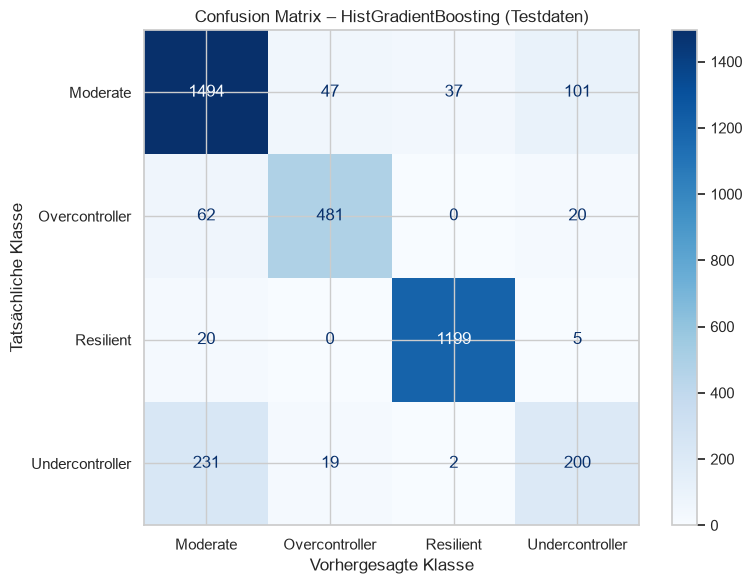

In [20]:
test_bar = show_progress("Finale Testbewertung", 0, 3)

# Die Testdaten werden jetzt erstmals für die finale Bewertung verwendet.
y_test_pred = best_pipeline.predict(X_test)
show_progress("Testvorhersagen erstellt", 1, 3, test_bar)

test_results_df = pd.DataFrame([{
    "Modell": winner_name,
    "Verfahren": winner_method,
    "CV F1-Macro": winner["CV F1-Macro"],
    "Test F1-Macro": f1_score(y_test, y_test_pred, average="macro"),
    "Test Accuracy": accuracy_score(y_test, y_test_pred)
}])
show_results_table(test_results_df)

class_report = classification_report(
    y_test, y_test_pred, output_dict=True, zero_division=0
)
class_report_df = pd.DataFrame({
    label: values for label, values in class_report.items()
    if isinstance(values, dict)
}).T.reset_index().rename(columns={
    "index": "Klasse / Durchschnitt",
    "support": "Anzahl Fälle"
})
print("Ergebnisse je Klasse:")
show_results_table(class_report_df)
show_progress("Testmetriken berechnet", 2, 3, test_bar)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=best_model.classes_,
    cmap="Blues",
    values_format="d",
    ax=ax
)
ax.set_title(f"Confusion Matrix – {winner_name} (Testdaten)")
ax.set_xlabel("Vorhergesagte Klasse")
ax.set_ylabel("Tatsächliche Klasse")
plt.tight_layout()
plt.show()
show_progress("Testbewertung abgeschlossen", 3, 3, test_bar);


Die Confusion Matrix zeigt, welche Persönlichkeitsklassen die Gewinner-Pipeline richtig erkennt und welche sie miteinander verwechselt. Die **Zeilen enthalten die tatsächlichen Klassen**, die **Spalten die vorhergesagten Klassen**. Werte auf der Diagonale stehen für richtige Vorhersagen; Werte außerhalb der Diagonale zeigen falsche Zuordnungen.

| Tatsächliche Klasse | Richtig erkannt | Anteil richtig erkannt |
|---|---:|---:|
| Moderate | 1.494 von 1.679 | 89,0 % |
| Overcontroller | 481 von 563 | 85,4 % |
| Resilient | 1.199 von 1.224 | 98,0 % |
| Undercontroller | 200 von 452 | 44,2 % |

Diese Anteile entsprechen dem **Recall** der jeweiligen Klasse. Resilient wird mit 98,0 % nahezu vollständig erkannt. Auch Moderate und Overcontroller werden mit 89,0 % beziehungsweise 85,4 % überwiegend richtig zugeordnet. Die größte Schwäche liegt bei Undercontroller: **231 Fälle werden fälschlich als Moderate vorhergesagt**, während nur 200 Fälle richtig erkannt werden. Damit werden 51,1 % der tatsächlichen Undercontroller-Fälle als Moderate eingestuft; der Recall beträgt 44,2 %.

Kleine Werte außerhalb der Diagonale zeigen seltenere Verwechslungen. Beispielsweise bedeutet der Wert **20 in der Zeile Resilient und der Spalte Moderate**, dass 20 tatsächliche Resilient-Fälle als Moderate vorhergesagt wurden. Umgekehrt wurden 37 tatsächliche Moderate-Fälle als Resilient eingestuft. Eine **0** bedeutet, dass diese Verwechslung im Testset nicht vorkam; sie garantiert nicht, dass sie bei künftigen Daten ausgeschlossen ist. Die Anzahl der Fehler sollte immer im Verhältnis zur Größe der jeweiligen Klasse betrachtet werden.

Insgesamt sind **3.374 von 3.918 Vorhersagen richtig (86,12 %)**. Diese Accuracy verdeckt jedoch die deutlich schwächere Erkennung von Undercontroller. Deshalb ergänzen F1-Macro und die Betrachtung einzelner Klassen die Gesamtbewertung. Die Matrix zeigt die beobachteten Verwechslungen, erklärt aber nicht deren Ursache.

# Alle CV-Ergebnisse grafisch vergleichen
Das Diagramm zeigt die 16 Kombinationen von Modell und Verfahren, sortiert nach CV-F1-Macro. Der beste Kandidat ist dunkelblau. Die Zahlen an den Balken erleichtern den Vergleich. Dieses Diagramm zeigt die für die Auswahl genutzten CV-Ergebnisse. Das Ergebnis bewertet, wie gut diese Zuordnung nachgebildet wird.

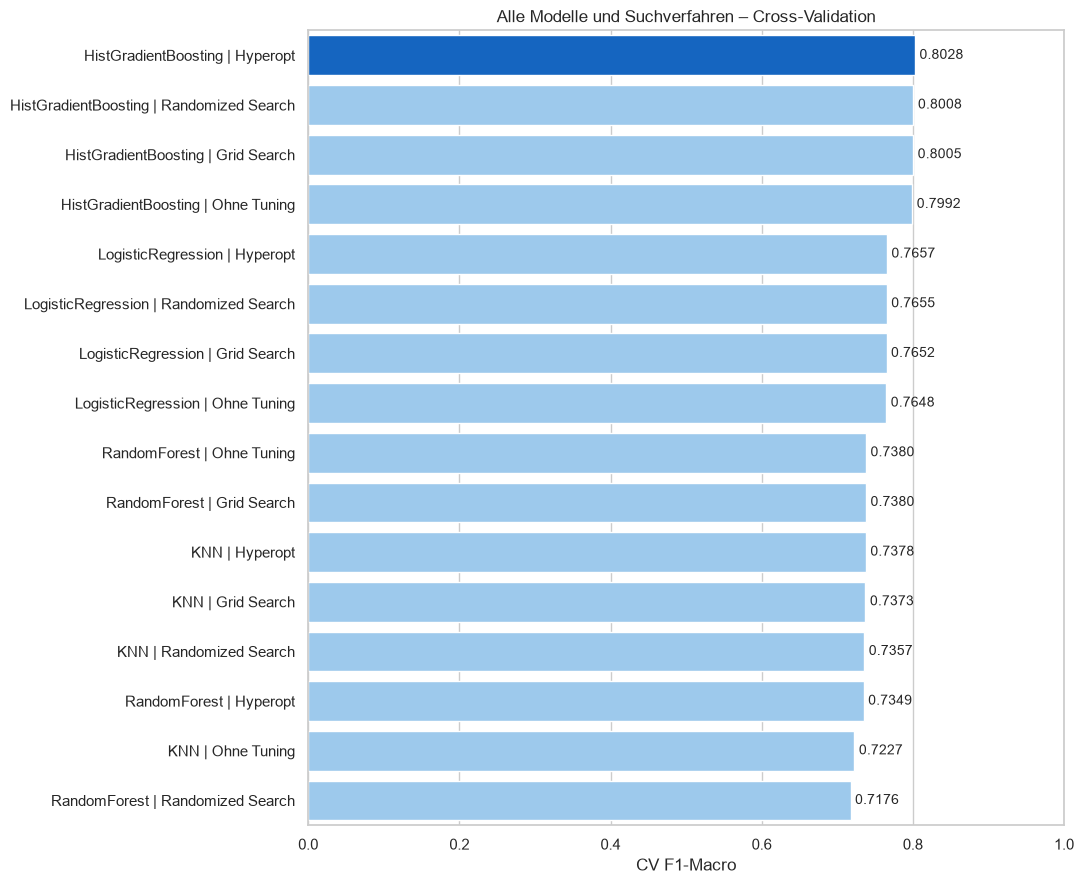

In [21]:
chart_bar = show_progress("Modellvergleich zeichnen", 0, 1)
plot_df = all_results_df.copy()
plot_df["Modell und Verfahren"] = (
    plot_df["Modell"] + " | " + plot_df["Verfahren"]
)

fig, ax = plt.subplots(figsize=(11, 9))
sns.barplot(
    data=plot_df,
    x="CV F1-Macro",
    y="Modell und Verfahren",
    order=plot_df["Modell und Verfahren"].tolist(),
    color="#90caf9",
    ax=ax
)
ax.patches[0].set_facecolor("#1565c0")
for bar, value in zip(ax.patches, plot_df["CV F1-Macro"]):
    ax.text(
        value + 0.006, bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}", va="center", fontsize=10
    )
ax.set_xlim(0, 1)
ax.set_title("Alle Modelle und Suchverfahren – Cross-Validation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
show_progress("Modellvergleich erstellt", 1, 1, chart_bar);


# Gewinner-Pipeline speichern
Wir speichern genau eine Datei: models/best_pipeline.joblib. Sie enthält die trainierte Vorverarbeitung und das trainierte Gewinner-Modell. Weitere Joblib- oder CSV-Dateien werden hier nicht erzeugt. Die Ergebnistabellen und Modellvergleiche bleiben im Notebook sichtbar.

In [22]:
save_bar = show_progress("Gewinner-Pipeline speichern", 0, 1)

# project_dir wurde beim Laden der CSV in Schritt 2 bestimmt.
save_dir = project_dir / "models"
save_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_pipeline, save_dir / "best_pipeline.joblib")
show_progress("Gewinner-Pipeline samt Modell gespeichert", 1, 1, save_bar)
print("Für neue Rohdaten models/best_pipeline.joblib verwenden.")




Für neue Rohdaten models/best_pipeline.joblib verwenden.


# Ergänzende Bemerkung
**Zusätzlich wurde CatBoost untersucht.**

 Das beste Ergebnis erreichte einen CV-F1-Macro von 0,8100 gegenüber 0,8028 bei HistGradientBoosting. Wegen des geringen Leistungszuwachses bei deutlich höherem Rechenaufwand wurde für dieses Projekt die bestehende HistGradientBoosting-Pipeline beibehalten.

# Abschlussdokumentation des Hauptworkflows
Dieser Abschnitt verwendet ausschließlich die bereits berechneten Ergebnisvariablen. Die Tabellen werden zur Übersicht erneut angezeigt. Es werden keine neuen Modelle trainiert, keine gespeicherten Dateien geändert und keine vorhandenen Variablen überschrieben. 


**Vorgehen und Auswahlkriterium**
Der bereinigte Datensatz enthält 19.587 Personen und 23 Spalten: 19 Frageantworten, age, gender, hand und die Zielvariable target. Nach Trennung der Zielvariable verbleiben 22 Eingabemerkmale.
Der Train-Test-Split reserviert 3.918 Fälle (20 %) für die finale Testbewertung. Modellvergleich und Hyperparameter-Suche verwenden ausschließlich die 15.669 Trainingsfälle (80 %). Auf diesen Trainingsdaten wird eine fünffache Cross-Validation mit gemischten Zeilen und random_state=42 durchgeführt. Preprocessing und Modell sind in einer Pipeline verbunden; Imputation, Skalierung und Encoding werden innerhalb der jeweiligen Trainingsaufteilungen gelernt.
Verglichen werden Logistic Regression, KNN, Random Forest und HistGradientBoosting. Für jedes Modell werden Ausgangseinstellungen, Grid Search, Randomized Search mit zwölf Versuchen und Hyperopt mit 20 Versuchen untersucht. Hyperopt beginnt mit fünf zufälligen Versuchen und nutzt danach TPE.

Hauptmetrik ist F1-Macro. Sie bildet für jede Klasse einen F1-Score aus Precision und Recall und mittelt die Klassen gleich gewichtet. Dadurch werden auch kleinere Klassen berücksichtigt. Accuracy wird ergänzend berichtet. Die Modellentscheidung basiert auf dem höchsten durchschnittlichen CV-F1-Macro und nicht auf dem späteren Testscore.

**Überblick über alle 16 Modellkonfigurationen**
Blau markiert ist der höchste CV-F1-Macro.

In [23]:

show_results_table(all_results_df, highlight_best=True)


Modell,Verfahren,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,Hyperopt,0.9340,0.8028,0.0057,0.8614
HistGradientBoosting,Randomized Search,0.9109,0.8008,0.0063,0.8614
HistGradientBoosting,Grid Search,0.8812,0.8005,0.0056,0.8613
HistGradientBoosting,Ohne Tuning,0.9411,0.7992,0.0083,0.8586
LogisticRegression,Hyperopt,0.7698,0.7657,0.0062,0.8527
LogisticRegression,Randomized Search,0.7697,0.7655,0.0060,0.8524
LogisticRegression,Grid Search,0.7697,0.7652,0.0061,0.8524
LogisticRegression,Ohne Tuning,0.7689,0.7648,0.0066,0.8523
RandomForest,Ohne Tuning,1.0000,0.7380,0.0045,0.8348
RandomForest,Grid Search,1.0000,0.7380,0.0045,0.8348


**Abschließende Modellentscheidung**
Nach dem Vergleich von vier Klassifikationsmodellen wurde HistGradientBoostingClassifier mit Hyperopt als finale Modellkonfiguration ausgewählt. Bereits ohne Tuning erreichte HistGradientBoosting den höchsten CV-F1-Macro der Ausgangsmodelle (0,7992). 

Die Hyperopt-Konfiguration erzielte mit allen Spalten den höchsten dokumentierten durchschnittlichen CV-F1-Macro von 0,8028, bei einer CV-Streuung von 0,0057 und einer CV-Accuracy von 
0,8614. Sie wurde deshalb ausgewählt und anschließend zusammen mit der Vorverarbeitung auf allen Trainingsdaten trainiert. Die unabhängige Abschlussbewertung auf 3.918 Testfällen ergab F1-Macro = 0,8030 und Accuracy = 0,8612. Die vollständige Pipeline einschließlich Vorverarbeitung und trainiertem Modell ist das Ergebnis für die spätere Streamlit-App und wird als eine Joblib-Datei gespeichert.

Die ausgewählten Hyperparameter lauten:

| Hyperparameter | Wert | Bedeutung |
|---|---:|---|
| `learning_rate` | 0,07814458302117205 | Schrittgröße des Boostings |
| `max_leaf_nodes` | 31 | Maximale Anzahl von Blättern je Baum |
| `l2_regularization` | 1.2994942824267277 | Regularisierung der Blattwerte |
| `max_iter` | 200 | Maximale Anzahl der Boosting-Iterationen |
| `random_state` | 42 | Fester Zufallsstart |

**Beurteilung der Verbesserung:** 

Der CV-F1 steigt gegenüber HistGradientBoosting ohne Tuning um 0,0036. Der Trainings-F1 sinkt von 0,9411 auf 0,9340; der Abstand zwischen Training und CV sinkt von 0,1419 auf 0,1312. Der Vorsprung gegenüber Randomized Search beträgt nur 0,0020 und ist klein im Verhältnis zur CV-Streuung. 

Logistic Regression erreicht in der besten getesteten Konfiguration 0,7657, Random Forest 0,7380 und KNN 0,7378. HistGradientBoosting liegt damit im Vergleich der Modellfamilien vorne. Der perfekte Trainings-F1 von Random Forest und KNN in mehreren Konfigurationen bedeutet keine perfekte Leistung auf neuen Daten; ihre deutlich niedrigeren CV-Scores deuten auf Überanpassung.

**Ergebnisse je Klasse**
Precision zeigt die Zuverlässigkeit einer vorhergesagten Klasse, Recall den Anteil erkannter tatsächlicher Fälle. F1 kombiniert beide Werte. Die Anzahl Fälle gibt die jeweilige Klassengröße im Testset an. Die Verwechslungen sind in der Confusion Matrix sichtbar.

In [24]:
# Bereits berechnete Ergebnisse je Klasse erneut anzeigen.
# rename erzeugt eine Anzeigeversion und verändert class_report_df nicht.
show_results_table(class_report_df.rename(columns={"support": "Anzahl Fälle"}))


Klasse / Durchschnitt,precision,recall,f1-score,Anzahl Fälle
Moderate,0.8268,0.8898,0.8571,1679.0
Overcontroller,0.8793,0.8544,0.8667,563.0
Resilient,0.9685,0.9796,0.9740,1224.0
Undercontroller,0.6135,0.4425,0.5141,452.0
macro avg,0.8220,0.7916,0.8030,3918.0
weighted avg,0.8540,0.8612,0.8554,3918.0


**Confusion Matrix der Gewinner-Pipeline**

Die bereits berechneten Testvorhersagen werden hier zur Übersicht erneut dargestellt. Die Grafik gehört zum Hauptworkflow mit allen Spalten und ist unabhängig von der optionalen Zusatzanalyse.

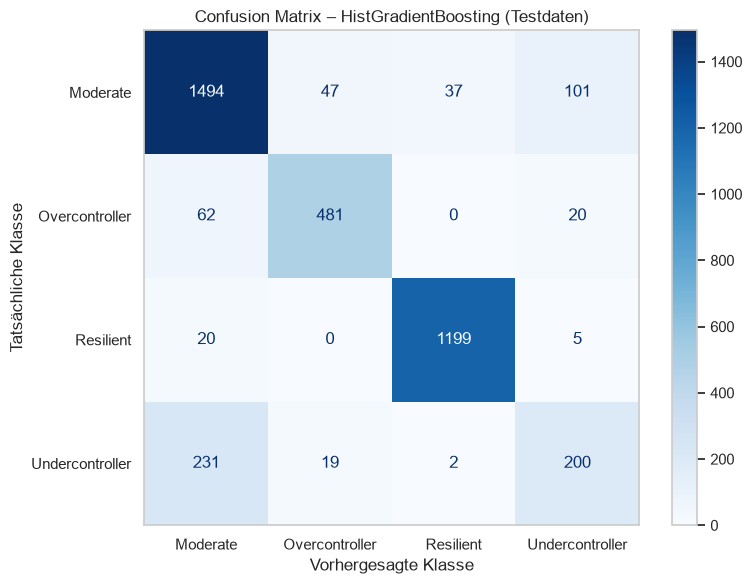

In [25]:
abschluss_matrix_bar = show_progress("Confusion Matrix anzeigen", 0, 1)

abschluss_matrix_fig, abschluss_matrix_ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=best_model.classes_,
    cmap="Blues",
    values_format="d",
    ax=abschluss_matrix_ax
)
abschluss_matrix_ax.set_title(f"Confusion Matrix – {winner_name} (Testdaten)")
abschluss_matrix_ax.set_xlabel("Vorhergesagte Klasse")
abschluss_matrix_ax.set_ylabel("Tatsächliche Klasse")
abschluss_matrix_ax.grid(False)
plt.tight_layout()
plt.show()
show_progress("Confusion Matrix angezeigt", 1, 1, abschluss_matrix_bar);


**Interpretation der Confusion Matrix**
Die Zeilen enthalten die tatsächlichen Klassen, die Spalten die vorhergesagten Klassen. Werte auf der Diagonale stehen für richtige Vorhersagen; Werte daneben zeigen Verwechslungen.

| Tatsächliche Klasse | Richtig erkannt | Anteil richtig erkannt (Recall) |
|---|---:|---:|
| Moderate | 1.494 von 1.679 | 89,0 % |
| Overcontroller | 481 von 563 | 85,4 % |
| Resilient | 1.199 von 1.224 | 98,0 % |
| Undercontroller | 200 von 452 | 44,2 % |

Resilient wird nahezu vollständig erkannt. Moderate und Overcontroller werden ebenfalls überwiegend richtig zugeordnet. Die größte Schwäche liegt bei Undercontroller: 231 Fälle werden als Moderate vorhergesagt, mehr als die 200 korrekt erkannten Fälle. Das betrifft rund 51,1 % der tatsächlichen Undercontroller-Fälle. Der Recall beträgt nur 44,2 %, der F1-Score 0,5141.

Ein kleiner Wert außerhalb der Diagonale bezeichnet eine seltenere Verwechslung. Resilient → Moderate: 20 bedeutet, dass 20 tatsächlich Resilient zugeordnete Personen fälschlich als Moderate vorhergesagt wurden. Umgekehrt wurden 37 tatsächliche Moderate-Fälle als Resilient eingestuft. Eine 0 bedeutet, dass diese Verwechslung in diesem Testset nicht vorkam; sie garantiert nicht, dass sie auf künftigen Daten ausgeschlossen ist.

Insgesamt sind 3.374 von 3.918 Vorhersagen richtig (86,12 %). Diese hohe Accuracy verdeckt die schwächere Erkennung der kleineren Klasse Undercontroller. F1-Macro und die Betrachtung einzelner Klassen ergänzen daher die Gesamtbewertung. Die Matrix zeigt die beobachteten Verwechslungen, erklärt aber nicht deren Ursache.

# Zusatzanalyse: Modellvergleich ohne eine Spalte

In [26]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


Im Dropdown wählen wir hand, gender oder age als zu entfernende Spalte. Standardmäßig ist hand gewählt. Wir entfernen die Spalte nur aus den Trainingsmerkmalen und vergleichen alle vier Modelle erneut, einschließlich Grid Search, Randomized Search und Hyperopt. Dadurch kann für diese Spaltenauswahl ein anderes Modell gewinnen. Die Ergebnisse mit allen Spalten werden aus den bisherigen Schritten wiederverwendet.

In [27]:
import ipywidgets as widgets

In [28]:
column_dropdown = widgets.Dropdown(
    options=["hand", "gender", "age"],
    value="hand",
    description="Weglassen:",
    style={"description_width": "initial"}
)
display(column_dropdown)


Dropdown(description='Weglassen:', options=('hand', 'gender', 'age'), style=DescriptionStyle(description_width…

In [29]:
# Die aktuelle Auswahl wird für diesen gesamten Vergleich übernommen.
excluded_column = column_dropdown.value
if excluded_column not in {"hand", "gender", "age"}:
    raise ValueError("Bitte hand, gender oder age auswählen; target bleibt unverändert.")

setup_bar = show_progress(f"Analyse ohne {excluded_column} vorbereiten", 0, 2)
without_X_train = X_train.drop(columns=[excluded_column]).copy()

without_numeric_features = [
    column for column in numeric_features if column != excluded_column
]
without_categorical_features = [
    column for column in categorical_features if column != excluded_column
]
show_progress("Spalte aus Trainingsmerkmalen entfernt", 1, 2, setup_bar)

without_preprocessor = ColumnTransformer([
    ("num", clone(numeric_pipeline), without_numeric_features),
    ("cat", clone(categorical_pipeline), without_categorical_features)
], remainder="drop", sparse_threshold=0)

without_pipelines = {}
for name, pipeline in pipelines.items():
    without_pipelines[name] = clone(pipeline).set_params(
        preprocessor=clone(without_preprocessor)
    )

show_progress("Vier neue Pipelines vorbereitet", 2, 2, setup_bar)
print("Entfernte Spalte:", excluded_column)
print("Eingabespalten:", without_X_train.columns.tolist())


Entfernte Spalte: hand
Eingabespalten: ['N6', 'N8', 'N7', 'N1', 'N9', 'N10', 'N3', 'N5', 'E3', 'N2', 'E5', 'N4', 'E7', 'E4', 'age', 'C4', 'E1', 'A4', 'E10', 'E9', 'gender']


In [30]:
without_results = []
without_timing_results = []

model_names = {
    "pipe_logreg": "LogisticRegression",
    "pipe_knn": "KNN",
    "pipe_rf": "RandomForest",
    "pipe_hgb": "HistGradientBoosting"
}

for name, pipeline in without_pipelines.items():
    model_name = model_names[name]
    model_bar = show_progress(f"CV ohne {excluded_column}: {model_name}", 0, cv.get_n_splits())

    start = time.time()

    # Jeden CV-Durchlauf einzeln ausführen, um echten Fortschritt zu zeigen.
    scores = {"train_f1_macro": [], "test_f1_macro": [], "test_accuracy": []}
    for fold, (train_indices, validation_indices) in enumerate(
        cv.split(without_X_train, y_train), start=1
    ):
        fold_scores = cross_validate(
            pipeline,
            without_X_train,
            y_train,
            cv=[(train_indices, validation_indices)],
            scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
            return_train_score=True,
            error_score="raise"
        )
        for metric in scores:
            scores[metric].append(fold_scores[metric][0])
        show_progress(f"CV ohne {excluded_column}: {model_name}", fold, cv.get_n_splits(), model_bar)

    # Arrays ermöglichen dieselbe Mittelwert-/Streuungsberechnung wie zuvor.
    scores = {metric: np.array(values) for metric, values in scores.items()}

    duration = time.time() - start
    without_timing_results.append({
        "Modell": model_name,
        "CV-Dauer (Sekunden)": duration
    })

    without_results.append({
        "Modell": model_name,
        "Train F1-Macro": scores["train_f1_macro"].mean(),
        "CV F1-Macro": scores["test_f1_macro"].mean(),
        "CV F1-Streuung": scores["test_f1_macro"].std(),
        "CV Accuracy": scores["test_accuracy"].mean()
    })

without_results_df = pd.DataFrame(without_results)
without_results_df = without_results_df.sort_values("CV F1-Macro", ascending=False).reset_index(drop=True)
show_results_table(without_results_df, highlight_best=True)
print("Blau, fett und kursiv: Modell mit dem höchsten CV-F1-Macro.")

# Zeit für alle fünf CV-Durchläufe je Pipeline, inklusive Vorverarbeitung.
without_timing_df = pd.DataFrame(without_timing_results)
print("Laufzeiten der Cross-Validation:")
show_results_table(without_timing_df, decimals=2, highlight_times=True)


Modell,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,0.9410,0.7986,0.0050,0.8593
LogisticRegression,0.7693,0.7649,0.0068,0.8524
RandomForest,1.0000,0.7340,0.0086,0.8348
KNN,0.8071,0.7212,0.0046,0.8076


Blau, fett und kursiv: Modell mit dem höchsten CV-F1-Macro.
Laufzeiten der Cross-Validation:


Modell,CV-Dauer (Sekunden)
LogisticRegression,2.47
KNN,2.61
RandomForest,8.15
HistGradientBoosting,8.16


In [31]:
without_grid_results = []
without_grid_timing_results = []
without_grid_parameter_results = []
without_grid_searches = {}
without_grid_bar = show_progress("Grid Search: vier Modelle", 0, len(without_pipelines))

for model_number, (name, pipeline) in enumerate(without_pipelines.items(), start=1):
    model_name = model_names[name]
    show_progress(f"Grid Search ohne {excluded_column}: {model_name}", model_number - 1, len(without_pipelines), without_grid_bar)

    without_grid_search = GridSearchCV(
        estimator=clone(pipeline),
        param_grid=param_grids[name],
        cv=cv,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        refit="f1_macro",
        return_train_score=True,
        n_jobs=1,
        error_score="raise"
    )

    start = time.time()
    without_grid_search.fit(without_X_train, y_train)
    duration = time.time() - start
    show_progress(f"Grid Search ohne {excluded_column}: {model_name} fertig", model_number, len(without_pipelines), without_grid_bar)

    # Ergebnisse und trainierte Gewinner-Pipeline dieses Suchlaufs behalten.
    without_grid_searches[name] = without_grid_search
    best_index = without_grid_search.best_index_
    search_scores = without_grid_search.cv_results_

    without_grid_results.append({
        "Modell": model_name,
        "Train F1-Macro": search_scores["mean_train_f1_macro"][best_index],
        "CV F1-Macro": search_scores["mean_test_f1_macro"][best_index],
        "CV F1-Streuung": search_scores["std_test_f1_macro"][best_index],
        "CV Accuracy": search_scores["mean_test_accuracy"][best_index]
    })
    without_grid_timing_results.append({
        "Modell": model_name,
        "Grid-Search-Dauer (Sekunden)": duration
    })
    without_grid_parameter_results.append({
        "Modell": model_name,
        "Beste Parameter": str(without_grid_search.best_params_)
    })

without_grid_results_df = pd.DataFrame(without_grid_results)
without_grid_results_df = without_grid_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

print("Grid Search: Ergebnisse der besten Einstellungen je Modell")
show_results_table(without_grid_results_df, highlight_best=True)
print("Blau, fett und kursiv: höchster CV-F1-Macro nach Grid Search.")

without_grid_timing_df = pd.DataFrame(without_grid_timing_results)
print("Laufzeiten inklusive abschließendem Training je Suchlauf:")
show_results_table(without_grid_timing_df, decimals=2, highlight_times=True)

without_grid_parameters_df = pd.DataFrame(without_grid_parameter_results)
print("Beste Parameter:")
display(HTML(table_css + without_grid_parameters_df.to_html(
    index=False, classes="pipeline-table", border=0
)))


Grid Search: Ergebnisse der besten Einstellungen je Modell


Modell,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,0.8809,0.8010,0.0054,0.8622
LogisticRegression,0.7696,0.7659,0.0076,0.8528
KNN,1.0000,0.7418,0.0057,0.8334
RandomForest,1.0000,0.7343,0.0065,0.8357


Blau, fett und kursiv: höchster CV-F1-Macro nach Grid Search.
Laufzeiten inklusive abschließendem Training je Suchlauf:


Modell,Grid-Search-Dauer (Sekunden)
LogisticRegression,6.91
KNN,16.34
RandomForest,77.69
HistGradientBoosting,58.41


Beste Parameter:


Modell,Beste Parameter
LogisticRegression,{'model__C': 10.0}
KNN,"{'model__n_neighbors': 15, 'model__weights': 'distance'}"
RandomForest,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}"
HistGradientBoosting,"{'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_leaf_nodes': 15}"


In [32]:
without_random_results = []
without_random_timing_results = []
without_random_parameter_results = []
without_random_searches = {}
without_random_bar = show_progress("Randomized Search: vier Modelle", 0, len(without_pipelines))

for model_number, (name, pipeline) in enumerate(without_pipelines.items(), start=1):
    model_name = model_names[name]
    show_progress(
        f"Randomized Search ohne {excluded_column}: {model_name}",
        model_number - 1, len(without_pipelines), without_random_bar
    )

    without_random_search = RandomizedSearchCV(
        estimator=clone(pipeline),
        param_distributions=param_distributions[name],
        n_iter=12,
        cv=cv,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        refit="f1_macro",
        return_train_score=True,
        random_state=42,
        n_jobs=1,
        error_score="raise"
    )

    start = time.time()
    without_random_search.fit(without_X_train, y_train)
    duration = time.time() - start
    show_progress(
        f"Randomized Search ohne {excluded_column}: {model_name} fertig",
        model_number, len(without_pipelines), without_random_bar
    )

    without_random_searches[name] = without_random_search
    best_index = without_random_search.best_index_
    search_scores = without_random_search.cv_results_

    without_random_results.append({
        "Modell": model_name,
        "Train F1-Macro": search_scores["mean_train_f1_macro"][best_index],
        "CV F1-Macro": search_scores["mean_test_f1_macro"][best_index],
        "CV F1-Streuung": search_scores["std_test_f1_macro"][best_index],
        "CV Accuracy": search_scores["mean_test_accuracy"][best_index]
    })
    without_random_timing_results.append({
        "Modell": model_name,
        "Randomized-Search-Dauer (Sekunden)": duration
    })
    without_random_parameter_results.append({
        "Modell": model_name,
        "Beste Parameter": str(without_random_search.best_params_)
    })

without_random_results_df = pd.DataFrame(without_random_results)
without_random_results_df = without_random_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

print("Randomized Search: Ergebnisse der besten Einstellungen je Modell")
show_results_table(without_random_results_df, highlight_best=True)

without_random_timing_df = pd.DataFrame(without_random_timing_results)
print("Laufzeiten inklusive abschließendem Training je Suchlauf:")
show_results_table(without_random_timing_df, decimals=2, highlight_times=True)

without_random_parameters_df = pd.DataFrame(without_random_parameter_results)
print("Beste Parameter:")
display(HTML(table_css + without_random_parameters_df.to_html(
    index=False, classes="pipeline-table", border=0
)))


Randomized Search: Ergebnisse der besten Einstellungen je Modell


Modell,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,0.9153,0.8019,0.0069,0.8616
LogisticRegression,0.7697,0.7659,0.0073,0.8528
KNN,1.0000,0.7372,0.0065,0.8418
RandomForest,0.8571,0.7113,0.0025,0.8274


Laufzeiten inklusive abschließendem Training je Suchlauf:


Modell,Randomized-Search-Dauer (Sekunden)
LogisticRegression,34.49
KNN,40.19
RandomForest,137.78
HistGradientBoosting,144.75


Beste Parameter:


Modell,Beste Parameter
LogisticRegression,{'model__C': np.float64(6.79657809075816)}
KNN,"{'model__n_neighbors': 32, 'model__weights': 'distance'}"
RandomForest,"{'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__n_estimators': 210}"
HistGradientBoosting,"{'model__l2_regularization': np.float64(0.2904180608409973), 'model__learning_rate': np.float64(0.146962368105409), 'model__max_iter': 200, 'model__max_leaf_nodes': 17}"


In [33]:
without_hyperopt_results = []
without_hyperopt_timing_results = []
without_hyperopt_parameter_results = []
without_hyperopt_pipelines = {}
without_hyperopt_trials = {}

for name, pipeline in without_pipelines.items():
    model_name = model_names[name]
    trials = Trials()
    completed_trials = [0]
    without_hyperopt_bar = show_progress(f"Hyperopt ohne {excluded_column}: {model_name}", 0, 20)

    # Hyperopt ruft diese Funktion mit einer neuen Parameterkombination auf.
    def without_objective(params):
        candidate = clone(pipeline).set_params(**params)
        scores = cross_validate(
            candidate,
            without_X_train,
            y_train,
            cv=cv,
            scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
            return_train_score=True,
            error_score="raise"
        )

        completed_trials[0] += 1
        show_progress(
            f"Hyperopt ohne {excluded_column}: {model_name}", completed_trials[0], 20, without_hyperopt_bar
        )

        # Hyperopt minimiert loss: negativer F1 wird bei besserem F1 kleiner.
        return {
            "loss": -scores["test_f1_macro"].mean(),
            "status": STATUS_OK,
            "train_f1": scores["train_f1_macro"].mean(),
            "cv_f1_std": scores["test_f1_macro"].std(),
            "cv_accuracy": scores["test_accuracy"].mean()
        }

    start = time.time()
    best = fmin(
        fn=without_objective,
        space=hyperopt_spaces[name],
        algo=partial(tpe.suggest, n_startup_jobs=5),
        max_evals=20,
        trials=trials,
        rstate=np.random.default_rng(42),
        show_progressbar=False,
        verbose=False
    )

    # space_eval übersetzt Auswahl-Indizes in tatsächliche Parameterwerte.
    best_params = space_eval(hyperopt_spaces[name], best)
    best_scores = trials.best_trial["result"]

    # Wie bei Grid/Randomized Search abschließend auf allen Trainingsdaten fitten.
    tuned_pipeline = clone(pipeline).set_params(**best_params)
    tuned_pipeline.fit(without_X_train, y_train)
    duration = time.time() - start

    without_hyperopt_pipelines[name] = tuned_pipeline
    without_hyperopt_trials[name] = trials
    without_hyperopt_results.append({
        "Modell": model_name,
        "Train F1-Macro": best_scores["train_f1"],
        "CV F1-Macro": -best_scores["loss"],
        "CV F1-Streuung": best_scores["cv_f1_std"],
        "CV Accuracy": best_scores["cv_accuracy"]
    })
    without_hyperopt_timing_results.append({
        "Modell": model_name,
        "Hyperopt-Dauer (Sekunden)": duration
    })
    without_hyperopt_parameter_results.append({
        "Modell": model_name,
        "Beste Parameter": str(best_params)
    })

without_hyperopt_results_df = pd.DataFrame(without_hyperopt_results)
without_hyperopt_results_df = without_hyperopt_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

print("Hyperopt: Ergebnisse der besten Einstellungen je Modell")
show_results_table(without_hyperopt_results_df, highlight_best=True)

without_hyperopt_timing_df = pd.DataFrame(without_hyperopt_timing_results)
print("Laufzeiten inklusive abschließendem Training je Suchlauf:")
show_results_table(without_hyperopt_timing_df, decimals=2, highlight_times=True)

without_hyperopt_parameters_df = pd.DataFrame(without_hyperopt_parameter_results)
print("Beste Parameter:")
display(HTML(table_css + without_hyperopt_parameters_df.to_html(
    index=False, classes="pipeline-table", border=0
)))


Hyperopt: Ergebnisse der besten Einstellungen je Modell


Modell,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,0.9173,0.8044,0.0071,0.8625
LogisticRegression,0.7698,0.7660,0.0073,0.8528
KNN,1.0000,0.7421,0.0031,0.8370
RandomForest,0.9780,0.7311,0.0048,0.8336


Laufzeiten inklusive abschließendem Training je Suchlauf:


Modell,Hyperopt-Dauer (Sekunden)
LogisticRegression,59.60
KNN,57.51
RandomForest,175.28
HistGradientBoosting,178.34


Beste Parameter:


Modell,Beste Parameter
LogisticRegression,{'model__C': 15.338010820281276}
KNN,"{'model__n_neighbors': 18, 'model__weights': 'distance'}"
RandomForest,"{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 60}"
HistGradientBoosting,"{'model__l2_regularization': 3.710827517994871, 'model__learning_rate': 0.15173284953685642, 'model__max_iter': 100, 'model__max_leaf_nodes': 21}"


In [ ]:
# Vier Modelle × vier Verfahren = 16 Ergebnisse.
without_all_results_df = pd.concat([
    without_results_df.assign(Verfahren="Ohne Tuning"),
    without_grid_results_df.assign(Verfahren="Grid Search"),
    without_random_results_df.assign(Verfahren="Randomized Search"),
    without_hyperopt_results_df.assign(Verfahren="Hyperopt")
], ignore_index=True)

without_all_results_df = without_all_results_df[[
    "Modell", "Verfahren", "Train F1-Macro", "CV F1-Macro",
    "CV F1-Streuung", "CV Accuracy"
]]
without_all_results_df = without_all_results_df.sort_values(
    "CV F1-Macro", ascending=False
).reset_index(drop=True)

show_results_table(without_all_results_df, highlight_best=True)
print("Die erste Zeile ist der beste Kandidat anhand des CV-F1-Macro.")
print("Für diese Zusatzanalyse wurden keine Testdaten verwendet.")


Modell,Verfahren,Train F1-Macro,CV F1-Macro,CV F1-Streuung,CV Accuracy
HistGradientBoosting,Hyperopt,0.9173,0.8044,0.0071,0.8625
HistGradientBoosting,Randomized Search,0.9153,0.8019,0.0069,0.8616
HistGradientBoosting,Grid Search,0.8809,0.8010,0.0054,0.8622
HistGradientBoosting,Ohne Tuning,0.9410,0.7986,0.0050,0.8593
LogisticRegression,Hyperopt,0.7698,0.7660,0.0073,0.8528
LogisticRegression,Randomized Search,0.7697,0.7659,0.0073,0.8528
LogisticRegression,Grid Search,0.7696,0.7659,0.0076,0.8528
LogisticRegression,Ohne Tuning,0.7693,0.7649,0.0068,0.8524
KNN,Hyperopt,1.0000,0.7421,0.0031,0.8370
KNN,Grid Search,1.0000,0.7418,0.0057,0.8334


Die erste Zeile ist der beste Kandidat anhand des CV-F1-Macro.
Die zurückgehaltenen Testdaten wurden noch nicht verwendet.


Beste gefundene Konfiguration je Datengrundlage:


Datengrundlage,Modell,Verfahren,CV F1-Macro,CV F1-Streuung,CV Accuracy,Veränderung CV-F1
Ohne hand,HistGradientBoosting,Hyperopt,0.8044,0.0071,0.8625,0.0016
Alle Spalten,HistGradientBoosting,Hyperopt,0.8028,0.0057,0.8614,0.0000


Vergleich je Modell nach erneuter Optimierung:


Modell,CV-F1 alle Spalten,CV-F1 ohne hand,Veränderung
HistGradientBoosting,0.8028,0.8044,0.0016
LogisticRegression,0.7657,0.7660,0.0003
RandomForest,0.7380,0.7343,-0.0037
KNN,0.7378,0.7421,0.0043


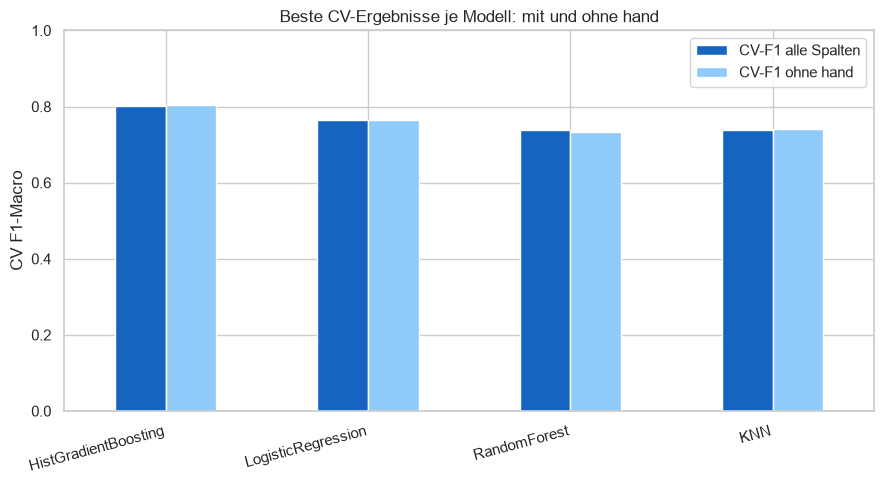

Änderung des besten CV-F1: +0.0016
Kleine Unterschiede sind kein Nachweis einer verlässlichen Verbesserung.
Gewinner-Pipeline, Testbewertung und gespeicherte Joblib bleiben unverändert.


In [35]:
compare_bar = show_progress("Mit und ohne Spalte vergleichen", 0, 2)

# Wiederverwenden der vorhandenen Ergebnisse mit allen Spalten.
reference_cv = all_results_df.iloc[0]["CV F1-Macro"]
ablation_summary_df = pd.concat([
    all_results_df.head(1).assign(Datengrundlage="Alle Spalten"),
    without_all_results_df.head(1).assign(
        Datengrundlage=f"Ohne {excluded_column}"
    )
], ignore_index=True)
ablation_summary_df["Veränderung CV-F1"] = (
    ablation_summary_df["CV F1-Macro"] - reference_cv
)
ablation_summary_df = ablation_summary_df[[
    "Datengrundlage", "Modell", "Verfahren", "CV F1-Macro",
    "CV F1-Streuung", "CV Accuracy", "Veränderung CV-F1"
]].sort_values("CV F1-Macro", ascending=False).reset_index(drop=True)

print("Beste gefundene Konfiguration je Datengrundlage:")
show_results_table(ablation_summary_df, highlight_best=True)

# Pro Modell dessen beste Konfiguration aus allen vier Verfahren vergleichen.
reference_models = all_results_df.drop_duplicates("Modell")[[
    "Modell", "CV F1-Macro"
]].rename(columns={"CV F1-Macro": "CV-F1 alle Spalten"})
without_models = without_all_results_df.drop_duplicates("Modell")[[
    "Modell", "CV F1-Macro"
]].rename(columns={"CV F1-Macro": f"CV-F1 ohne {excluded_column}"})
ablation_models_df = reference_models.merge(without_models, on="Modell")
ablation_models_df["Veränderung"] = (
    ablation_models_df[f"CV-F1 ohne {excluded_column}"]
    - ablation_models_df["CV-F1 alle Spalten"]
)
print("Vergleich je Modell nach erneuter Optimierung:")
show_results_table(ablation_models_df)
show_progress("Vergleichstabellen erstellt", 1, 2, compare_bar)

fig, ax = plt.subplots(figsize=(9, 5))
ablation_models_df.set_index("Modell")[[
    "CV-F1 alle Spalten", f"CV-F1 ohne {excluded_column}"
]].plot.bar(ax=ax, color=["#1565c0", "#90caf9"])
ax.set_ylim(0, 1)
ax.set_title(f"Beste CV-Ergebnisse je Modell: mit und ohne {excluded_column}")
ax.set_ylabel("CV F1-Macro")
ax.set_xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

delta = without_all_results_df.iloc[0]["CV F1-Macro"] - reference_cv
print(f"Änderung des besten CV-F1: {delta:+.4f}")
print("Kleine Unterschiede sind kein Nachweis einer verlässlichen Verbesserung.")
print("Gewinner-Pipeline, Testbewertung und gespeicherte Joblib bleiben unverändert.")
show_progress("Vergleich abgeschlossen", 2, 2, compare_bar);
